# 4f. Evaluate transfer predictions

Notebooks **4c** and **4d** focus on ED admissions and yet-to-arrive bed demand. Production at UCLH also predicts **inpatient outflows**: patients leaving a subspecialty either by **internal transfer** to another specialty or by **discharge** from hospital. This notebook evaluates the **transfer-routing** part of that system — whether observed destinations from each source specialty match the model's patient-level routing tables.

Throughout, **departure** means leaving the **current subspecialty**, not necessarily leaving the hospital. A departure event ends up in another specialty's column or in the `Discharge` column of the routing table.

Production transfer prediction uses **subgroup routing** (the same age/sex subgroup idea as notebook **4b**, but applied here to transfers rather than ED admissions). Each departing patient is assigned to a subgroup; their routing vector comes from that subgroup's fitted table. Age and sex matter because they let the model down-weight implausible routes (for example, sending a male patient to gynaecology). Each departure is therefore a draw from `Categorical(p_i)` where `p_i` is **patient-specific** (via age/sex subgroup routing), not from a single source-level probability vector.

Notebook **4d** showed how `patientflow.evaluate` scores classifiers, bed-demand PMFs, and yet-to-arrive arrival rates. This notebook adds the sixth evaluation mode: **`transition_matrix`**, which checks whether that transfer routing is calibrated at each source subspecialty.

The transition-matrix evaluation asks a **conditional** question:

> Given that patients departed from source `s` during the evaluation window, with the subgroup mix that actually left, do their observed destinations match the routing the model would have applied patient-by-patient?

The test compares **observed destination counts** (transfers to each specialty plus discharges) to **patient-level expected counts** `E_d = Σ_i p_i(d)`, where each row `p_i` is built from the patient's subgroup table. A Monte Carlo **Pearson X²** test simulates specialty departures by drawing each event from its own `Categorical(p_i)` — not from one shared `Multinomial(N, p̄)`.

For each departing patient, the routing vector `p_i` encodes two linked decisions: whether they **discharge from hospital** or **transfer internally**, and — if they transfer — **which specialty** they go to. The Pearson test rolls both into one summary p-value per source, so a flagged source may have the wrong discharge rate, the wrong transfer destinations, or both. Compare the stored expected and observed counts destination by destination (especially `Discharge` versus the specialty columns) to see which part is miscalibrated.

**What this mode does not test:**

- **Departure volume from a source** — the test is conditional on `N` patients having left that specialty. If Acute Medicine releases twice as many patients as the model expected, every row can still pass; checking departure *rates* is a separate evaluation.
- **Column-level inflow calibration** — each source is tested on its own outflows. Respiratory could receive the right *total* number of transfers while those patients come from the wrong sources; every source row might pass even though the destination column is wrong.
- **Routing drift within the window** — all departures from a source in the evaluation window are pooled into one test. A pathway change mid-window (routing correct before and after, wrong in between) can look like miscalibration rather than a timing effect.
- **Cross-source correlations** — sources are scored independently. Coordinated shifts across several specialties (for example, a hospital-wide bed-management policy) are not modelled.
- **Subgroup classifier accuracy** — the test treats each patient's age/sex subgroup as given. If subgroups are misassigned at fit or predict time, that error affects both the expected counts and the simulated draws, and this test cannot detect it.

This notebook generates **fake transfer history on-the-fly** (no UCLH data required) and walks through:

1. **Fit** a `TransferProbabilityEstimator` with sex-split routing from Acute Medicine.
2. **Build** per-patient routing vectors and aggregate expected counts.
3. **Register** evaluation departure events and run the Pearson goodness-of-fit test directly.
4. **Wire** `EvaluationInputsBuilder` / `run_evaluation` and inspect scalar rows in `scalars.json`.


In [1]:
# Reload functions every time
%load_ext autoreload
%autoreload 2

## 1. Fit a transfer model on fake history

We use a deliberately simple routing story so the evaluation is easy to follow. At UCLH, a typical transfer from **Acute Medicine** might be to **Care of the Elderly** or **Respiratory**. Neither destination is sex-exclusive, which makes a clean subgroup demo harder. Here we use **gynaecology** for female patients and **urology** for male patients instead: both are plausible inpatient destinations, and the sex split matches the subgroup tables the estimator fits.

- **Acute Medicine, female** → **gynaecology**
- **Acute Medicine, male** → **urology**
- **Care of the Elderly** patients mostly **discharge** (no internal transfer in the training history)

The fitted estimator stores subgroup-specific tables under `transfer_probabilities[cohort]["subgroups"]`. Production and this evaluation both route patient-by-patient from those tables.

In [2]:
import numpy as np
import pandas as pd
from IPython.display import display

from patientflow.predictors.transfer_predictor import TransferProbabilityEstimator

services = [
    "acute medicine",
    "care of the elderly",
    "respiratory",
    "gynaecology",
    "urology",
]
cohort = "emergency"
source = "acute medicine"

females = pd.DataFrame(
    {
        "current_subspecialty": [source] * 40,
        "next_subspecialty": ["gynaecology"] * 40,
        "admission_type": [cohort] * 40,
        "age_on_arrival": [30] * 40,
        "sex": ["F"] * 40,
    }
)
males = pd.DataFrame(
    {
        "current_subspecialty": [source] * 40,
        "next_subspecialty": ["urology"] * 40,
        "admission_type": [cohort] * 40,
        "age_on_arrival": [30] * 40,
        "sex": ["M"] * 40,
    }
)
discharges = pd.DataFrame(
    {
        "current_subspecialty": ["care of the elderly"] * 20,
        "next_subspecialty": [None] * 20,
        "admission_type": [cohort] * 20,
        "age_on_arrival": [82] * 20,
        "sex": ["F"] * 20,
    }
)

training_history = pd.concat([females, males, discharges], ignore_index=True)
transfer_model = TransferProbabilityEstimator(cohort_col="admission_type")
transfer_model.fit(training_history, set(services))

destinations = list(transfer_model.get_transition_matrix(cohort).columns)
print(f"Fitted transfer model with {len(services)} services and {len(destinations)} destination columns")

Fitted transfer model with 5 services and 6 destination columns


## 2. Per-patient routing vectors

Within the trained instance of `TransferProbabilityEstimator`, the method `build_per_patient_probabilities` resolves each departing patient's subgroup and reads that subgroup's routing row. Summing the rows gives patient-level expected counts `E`; that is what the Pearson test compares to observed destination counts (shown later).

For each event `i`, the vector `p_i` is built as `p_i(T) = q_transfer_i × q_dest_i(T)` for transfer destinations `T`, and `p_i(Discharge) = 1 − q_transfer_i`.

To demonstrate the `build_per_patient_probabilities` method, we create two example events.

In [3]:
from patientflow.predict.transfers import build_per_patient_probabilities

# Two hypothetical departures from Acute Medicine (one female, one male).
# next_subspecialty is the observed destination in evaluation data; here it
# illustrates plausible routes, but build_per_patient_probabilities reads
# age/sex to look up model probabilities, not this column.
example_events = pd.DataFrame(
    {
        "current_subspecialty": [source, source],  # source specialty each patient is leaving
        "next_subspecialty": ["gynaecology", "urology"],  # where they went (observed destination)
        "admission_type": [cohort, cohort],  # elective/emergency cohort key for the fitted tables
        "age_on_arrival": [30, 30],  # used with sex to resolve the patient's subgroup
        "sex": ["F", "M"],  # resolves to female vs male subgroup routing rows
    }
)

# For each row, look up subgroup routing and return a probability vector p_i
# over all destination columns (specialties plus Discharge).
#
pp = build_per_patient_probabilities(
    example_events,
    source,  # filter to departures leaving this source specialty
    cohort,  # which cohort's subgroup tables to read
    destinations,  # column order aligned with the fitted estimator
    transfer_model,
)

# pp.routing_matrix has shape (n_events, n_destinations): one routing row per departure.
pp_df = pd.DataFrame(pp.routing_matrix, columns=destinations, index=["female_patient", "male_patient"])
print("Per-patient routing vectors p_i (rows sum to 1):")
display(pp_df.round(3))

Per-patient routing vectors p_i (rows sum to 1):


,acute medicine,care of the elderly,gynaecology,respiratory,urology,Discharge
female_patient,0.0,0.0,1.0,0.0,0.0,0.0
male_patient,0.0,0.0,0.0,0.0,1.0,0.0


## 3. Evaluation departure events

Now we will run an evaluation assuming we have a test set recording 30 departure events that occurred during an evaluation window. We register one row per **observed departure**. (Note that the caller must pre-filter to the window; the builder does not apply a date filter.)

We include:

- **Acute Medicine**: 30 departures with the expected sex split and destinations (well calibrated).
- **Respiratory**: a few discharges (destinations `None` → `Discharge`).
- **Care of the Elderly**: no departures in this window (handler will emit a skip row).

We also keep a separate **miscalibrated** Acute Medicine frame (all females routed to urology instead of gynaecology) for the direct goodness-of-fit demo in section 5.

In [4]:
n_female = 15
n_male = 15

eval_events = pd.DataFrame(
    {
        "current_subspecialty": [source] * (n_female + n_male)
        + ["respiratory"] * 4,
        "next_subspecialty": ["gynaecology"] * n_female
        + ["urology"] * n_male
        + [None] * 4,
        "admission_type": [cohort] * (n_female + n_male + 4),
        "age_on_arrival": [30] * (n_female + n_male) + [65] * 4,
        "sex": ["F"] * n_female + ["M"] * n_male + ["M"] * 4,
    }
)

miscalibrated_events = pd.DataFrame(
    {
        "current_subspecialty": [source] * 80,
        "next_subspecialty": ["urology"] * 80,
        "admission_type": [cohort] * 80,
        "age_on_arrival": [30] * 80,
        "sex": ["F"] * 80,
    }
)

print(f"Evaluation window departures: {len(eval_events)}")
print(eval_events.groupby(["current_subspecialty", "next_subspecialty"]).size())

Evaluation window departures: 34
current_subspecialty  next_subspecialty
acute medicine        gynaecology          15
                      urology              15
dtype: int64


## 4. Expected vs observed counts for one source

Before running the Pearson test in section 5, this section shows the two count vectors the test compares — expected from the model and observed from the data.

For source **Acute Medicine**, filter events, build the routing matrix, and aggregate:

- `E = routing_matrix.sum(axis=0)` — patient-level expected counts per destination
- `n_obs` — observed destination counts from `next_subspecialty` (`None` counts as `Discharge`)

When the subgroup mix matches the model and destinations follow routing, `E` and `n_obs` should align closely, as illustrated in the figure.

Acute Medicine: 30 departures, 2 subgroups used, 0 unmatched (all-discharge)


,expected,observed
acute medicine,0.0,0
care of the elderly,0.0,0
gynaecology,15.0,15
respiratory,0.0,0
urology,15.0,15
Discharge,0.0,0


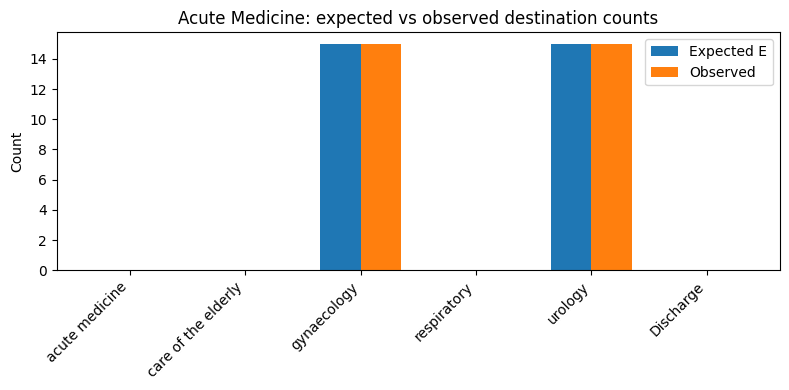

In [5]:
import matplotlib.pyplot as plt

source_events = eval_events.loc[eval_events["current_subspecialty"] == source]
pp_source = build_per_patient_probabilities(
    source_events, source, cohort, destinations, transfer_model
)
expected = pp_source.routing_matrix.sum(axis=0)

n_obs = np.zeros(len(destinations), dtype=int)
dest_to_idx = {d: i for i, d in enumerate(destinations)}
for dest in source_events["next_subspecialty"]:
    key = "Discharge" if dest is None or pd.isna(dest) else str(dest)
    n_obs[dest_to_idx[key]] += 1

comparison = pd.DataFrame(
    {"expected": expected, "observed": n_obs}, index=destinations
)
print(
    f"Acute Medicine: {len(source_events)} departures, "
    f"{pp_source.n_subgroups_used} subgroups used, "
    f"{pp_source.n_excluded_unmatched} unmatched (all-discharge)"
)
display(comparison.round(2))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(destinations))
width = 0.35
ax.bar(x - width / 2, expected, width, label="Expected E")
ax.bar(x + width / 2, n_obs, width, label="Observed")
ax.set_xticks(x)
ax.set_xticklabels(destinations, rotation=45, ha="right")
ax.set_ylabel("Count")
ax.set_title("Acute Medicine: expected vs observed destination counts")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Monte Carlo Pearson test (direct call)

Section 4 showed whether `E` and `n_obs` align by eye; this section turns that comparison into a formal goodness-of-fit test and p-value.

Because each departure has its own routing vector, there is no simple formula for the p-value. **Monte Carlo simulation** replays the same `N` departures many times: on each replay, every patient gets a fresh simulated destination drawn from their own `Categorical(p_i)`, we recount destinations, and compute a Pearson statistic. Comparing the observed statistic to this simulated distribution yields the p-value.

`multinomial_gof_montecarlo` in `patientflow.evaluate.goodness_of_fit` implements the test as follows:

1. Compute `T_obs = Pearson(n_obs, E)` using only destinations with `E_d > 0`.
2. For each simulation, draw one destination per event from `Categorical(p_i)`, aggregate counts, and compute `T_sim`.
3. Return `p_value = (1 + count(T_sim >= T_obs)) / (M + 1)` (the +1 correction keeps the p-value valid when `T_obs` is extreme).

Destinations with `E_d = 0` are omitted from the Pearson sum. If any observed count lands on such a destination, that is a **structural violation** — the model assigned zero probability to a destination that received traffic — and is reported separately on the scalar row.

We use Pearson X² rather than a G-statistic because, once routing is patient-specific, the null is no longer a homogeneous multinomial. Pearson is defined directly on `(n_d − E_d)` aggregated from per-patient residuals.

The **p-value** is the proportion of simulated replays at least as mismatched as the data we saw: **low** values suggest the overall pattern of observed destinations is unlikely if the model were correct; **high** values mean the observed counts are plausible under the model. Well-calibrated Acute Medicine events should score high; our miscalibrated example (females sent to urology instead of gynaecology) should score low. Also note **`N`** (the number of departures): with only a few events, counts can look odd by chance even when routing is fine; with larger `N`, a low p-value is stronger evidence of genuine miscalibration.

In [6]:
from patientflow.evaluate.goodness_of_fit import multinomial_gof_montecarlo


def run_gof(events: pd.DataFrame, source_name: str, *, seed: int = 7) -> None:
    source_events = events.loc[events["current_subspecialty"] == source_name]
    pp = build_per_patient_probabilities(
        source_events, source_name, cohort, destinations, transfer_model
    )
    n_obs_local = np.zeros(len(destinations), dtype=int)
    for dest in source_events["next_subspecialty"]:
        key = "Discharge" if dest is None or pd.isna(dest) else str(dest)
        n_obs_local[dest_to_idx[key]] += 1
    result = multinomial_gof_montecarlo(
        pp.routing_matrix, n_obs_local, destinations, n_simulations=2000, seed=seed
    )
    print(
        f"{source_name}: N={result.n_observed}, "
        f"Pearson X²={result.pearson_x2:.2f}, p={result.p_value:.4f}, "
        f"structural_violations={result.n_structural_violations}"
    )


print("Well-calibrated evaluation events:")
run_gof(eval_events, source)

print("\nMiscalibrated events (females observed at urology, model expects gynaecology):")
run_gof(miscalibrated_events, source, seed=11)

Well-calibrated evaluation events:


acute medicine: N=30, Pearson X²=0.00, p=1.0000, structural_violations=0

Miscalibrated events (females observed at urology, model expects gynaecology):


acute medicine: N=80, Pearson X²=80.00, p=0.0005, structural_violations=1


## 6. Wire the evaluate package

Sections 2–5 ran the test step by step on our fake data, for one source at a time. In production we use the same `patientflow.evaluate` framework as notebook **4d**: declare a target, register the fitted transfer model and departure events on the builder, then let `run_evaluation` score every source and write the results to `scalars.json`.

The pattern matches **4d**, but with a single **`transition_matrix`** target and **`add_transition_matrix`** on the builder.

| Field | Value in this notebook |
|-------|------------------------|
| `evaluation_mode` | `"transition_matrix"` |
| `flow_name` | `"inpatient_transfers"` (must match `add_transition_matrix`) |
| `flow_type` | `"departures"` (reporting label) |
| `component` | `"transition_matrix_row"` (scalar family name) |
| `observation_mode` | omitted (not used for this mode) |

The handler emits **one scalar row per estimator source** (active or skipped). Skip reasons include:

- `no_observed_departures` — no traffic from that source in the window
- `all_discharge_expected` — every event resolves to all-discharge routing (degenerate Pearson test)

Active rows store `destinations`, `expected_counts`, `observed_counts`, `pearson_x2`, and `p_value`. The `reliable` flag is true when `n_departures >= 30` (`RELIABILITY_MIN_OBSERVATIONS_TRANSITION`).

In [7]:
from datetime import timedelta

from patientflow.evaluate.inputs import EvaluationInputsBuilder, EvaluationTarget
from patientflow.predict.demand import FlowSelection

prediction_time = (6, 0)
prediction_dict = {prediction_time: timedelta(hours=8)}

transition_target = EvaluationTarget(
    flow_name="inpatient_transfers",
    flow_type="departures",
    evaluation_mode="transition_matrix",
    component="transition_matrix_row",
)

builder = (
    EvaluationInputsBuilder(
        flow_selection=FlowSelection.custom(
            include_ed_current=False,
            include_ed_yta=False,
            include_non_ed_yta=False,
            include_elective_yta=False,
            include_transfers_in=True,
            include_departures=True,
        ),
        prediction_dict=prediction_dict,
    )
    .with_evaluation_targets([transition_target])
    .add_transition_matrix(
        "inpatient_transfers",
        transfer_model,
        eval_events,
        cohort=cohort,
        n_simulations=2000,
        seed=99,
    )
)

inputs = builder.build()
print(f"Registered target: {transition_target.evaluation_mode} / {transition_target.flow_name}")

Registered target: transition_matrix / inpatient_transfers


## 7. Run evaluation

`run_evaluation` writes `scalars.json` under a timestamped directory. Transition-matrix mode does not produce PNG charts (`charts_generated: false`); drill-down uses the stored count vectors.

In [8]:
import json
from datetime import datetime
from pathlib import Path

from patientflow.evaluate.runner import run_evaluation

run_name = f"notebook4f_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
out = run_evaluation(
    Path("eval-output"),
    inputs,
    run_name=run_name,
    charts="all",
)

## 8. Inspect scalar rows

Load `evaluation_rows` and the `_service_summary` slice for this target. Rank active sources by p-value and inspect expected vs observed vectors for any flagged source.

In [9]:
from IPython.display import display

scalars_path = out["scalars_path"]
payload = json.loads(scalars_path.read_text(encoding="utf-8"))
rows = payload["evaluation_rows"]
tm_rows = [r for r in rows if r["evaluation_mode"] == "transition_matrix"]

summary_key = "transition_matrix/inpatient_transfers/transition_matrix_row"
summary = payload["_service_summary"]["by_slice"][summary_key]
print("Service summary:", summary)

base_cols = [
    "service",
    "n_departures",
    "skip_reason",
    "pearson_x2",
    "p_value",
    "reliable",
    "n_excluded_unmatched",
]
tm_df = pd.DataFrame(tm_rows)
display(tm_df[[c for c in base_cols if c in tm_df.columns]])

if "skip_reason" in tm_df.columns:
    active = tm_df[tm_df["skip_reason"].isna()]
else:
    active = tm_df

if not active.empty and "destinations" in active.columns:
    am_row = active.loc[active["service"] == source].iloc[0]
    drill = pd.DataFrame(
        {
            "expected": am_row["expected_counts"],
            "observed": am_row["observed_counts"],
        },
        index=am_row["destinations"],
    )
    print(f"\n{source.title()} drill-down from scalars.json:")
    display(drill.round(2))

Service summary: {'mode': 'transition_matrix', 'flow': 'inpatient_transfers', 'component': 'transition_matrix_row', 'cohort': 'emergency', 'n_active_sources': 1, 'n_skipped_sources': 4, 'skipped_by_reason': {'no_observed_departures': 3, 'all_discharge_expected': 1}, 'n_excluded_unmatched_departures': 4}


,service,n_departures,skip_reason,pearson_x2,p_value,reliable,n_excluded_unmatched
0,acute medicine,30,NaN,0.0,1.0,True,0.0
1,care of the elderly,0,no_observed_departures,NaN,NaN,False,NaN
2,gynaecology,0,no_observed_departures,NaN,NaN,False,NaN
3,respiratory,4,all_discharge_expected,NaN,NaN,False,NaN
4,urology,0,no_observed_departures,NaN,NaN,False,NaN



Acute Medicine drill-down from scalars.json:


,expected,observed
acute medicine,0.0,0
care of the elderly,0.0,0
gynaecology,15.0,15
respiratory,0.0,0
urology,15.0,15
Discharge,0.0,0


## Summary

In this notebook we fitted a transfer model on fake Acute Medicine routing, built per-patient expected counts, compared them to observed destinations, ran the Monte Carlo Pearson test directly, and then wired the same check into `patientflow.evaluate` to produce scalar rows in `scalars.json`.

1. **Production and evaluation** both route departures patient-by-patient from subgroup tables (`transfer_probabilities[cohort]["subgroups"][g]`).
2. **`build_per_patient_probabilities`** assembles per-event vectors `p_i`; summing rows gives patient-level expectations `E`.
3. **`multinomial_gof_montecarlo`** runs a Monte Carlo Pearson test by simulating each departure from its own `Categorical(p_i)`.
4. **`EvaluationTarget(evaluation_mode="transition_matrix")`** plus **`add_transition_matrix`** integrates the test into `run_evaluation`, emitting one scalar row per source and a `_service_summary` slice.

For flagged sources with sufficient `N`, compare `expected_counts` and `observed_counts` per destination to distinguish a transfer-rate error (the `Discharge` slot) from a destination-mix error among transferred patients.